# Баринов Артемий Андреевич ИУ5-62Б

Вариант 3   Задание 1   Датасет 3

Задача №1.
Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

Дополнительные требования по группам: для произвольной колонки данных построить гистограмму.

Набор данных: https://www.kaggle.com/carlolepelaars/toy-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder



In [ ]:
df = pd.read_csv('toy_dataset.csv')

print(df.shape)
print(df.dtypes)
print(f"\nКол-во пропусков:\n{df.isnull().sum()}")
print(df.head)
print(df.describe())

(150000, 6)
Number       int64
City           str
Gender         str
Age          int64
Income     float64
Illness        str
dtype: object

Кол-во пропусков:
Number     0
City       0
Gender     0
Age        0
Income     0
Illness    0
dtype: int64
<bound method NDFrame.head of         Number    City  Gender  Age    Income Illness
0            1  Dallas    Male   41   40367.0      No
1            2  Dallas    Male   54   45084.0      No
2            3  Dallas    Male   42   52483.0      No
3            4  Dallas    Male   40   40941.0      No
4            5  Dallas    Male   46   50289.0      No
...        ...     ...     ...  ...       ...     ...
149995  149996  Austin    Male   48   93669.0      No
149996  149997  Austin    Male   25   96748.0      No
149997  149998  Austin    Male   26  111885.0      No
149998  149999  Austin    Male   25  111878.0      No
149999  150000  Austin  Female   37   87251.0      No

[150000 rows x 6 columns]>
              Number            Age         

### Пропусков нет, доп. обработка не требуется

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Number')
print(f"\nЧисловые столбцы: {num_cols}")



Числовые столбцы: ['Age', 'Income']


## Нормализация числовых данных

In [ ]:
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler_minmax.fit_transform(df[num_cols])

print("После  нормализации:")
print(df_minmax[num_cols].head())

df = df_minmax

После  нормализации:
     Age    Income
0  0.400  0.230700
1  0.725  0.257228
2  0.425  0.298840
3  0.375  0.233928
4  0.525  0.286501


## Кодирование категориальных данных

In [ ]:
df_enc = df.copy()
df_enc['Illness_enc'] = df_enc['Illness'].map({'Yes': 1, 'No': 0})
df_enc['Gender_enc'] = df_enc['Gender'].map({'Male': 1, 'Female': 0})
le_city = LabelEncoder()
df_enc['City_enc'] = le_city.fit_transform(df_enc['City'])

print(df_enc[['City', 'City_enc', 'Gender', 'Gender_enc', 'Illness', 'Illness_enc']].head())

encoded_cols = ['Illness_enc', 'Gender_enc', 'City_enc']

all_num_cols = num_cols + encoded_cols
df_num = df_enc[all_num_cols]

print(f"Числовые столбцы + закодированные: {all_num_cols}")

     City  City_enc Gender  Gender_enc Illness  Illness_enc
0  Dallas         2   Male           1      No            0
1  Dallas         2   Male           1      No            0
2  Dallas         2   Male           1      No            0
3  Dallas         2   Male           1      No            0
4  Dallas         2   Male           1      No            0
Числовые столбцы + закодированные: ['Age', 'Income', 'Illness_enc', 'Gender_enc', 'City_enc']


## Гистограммы столбцов

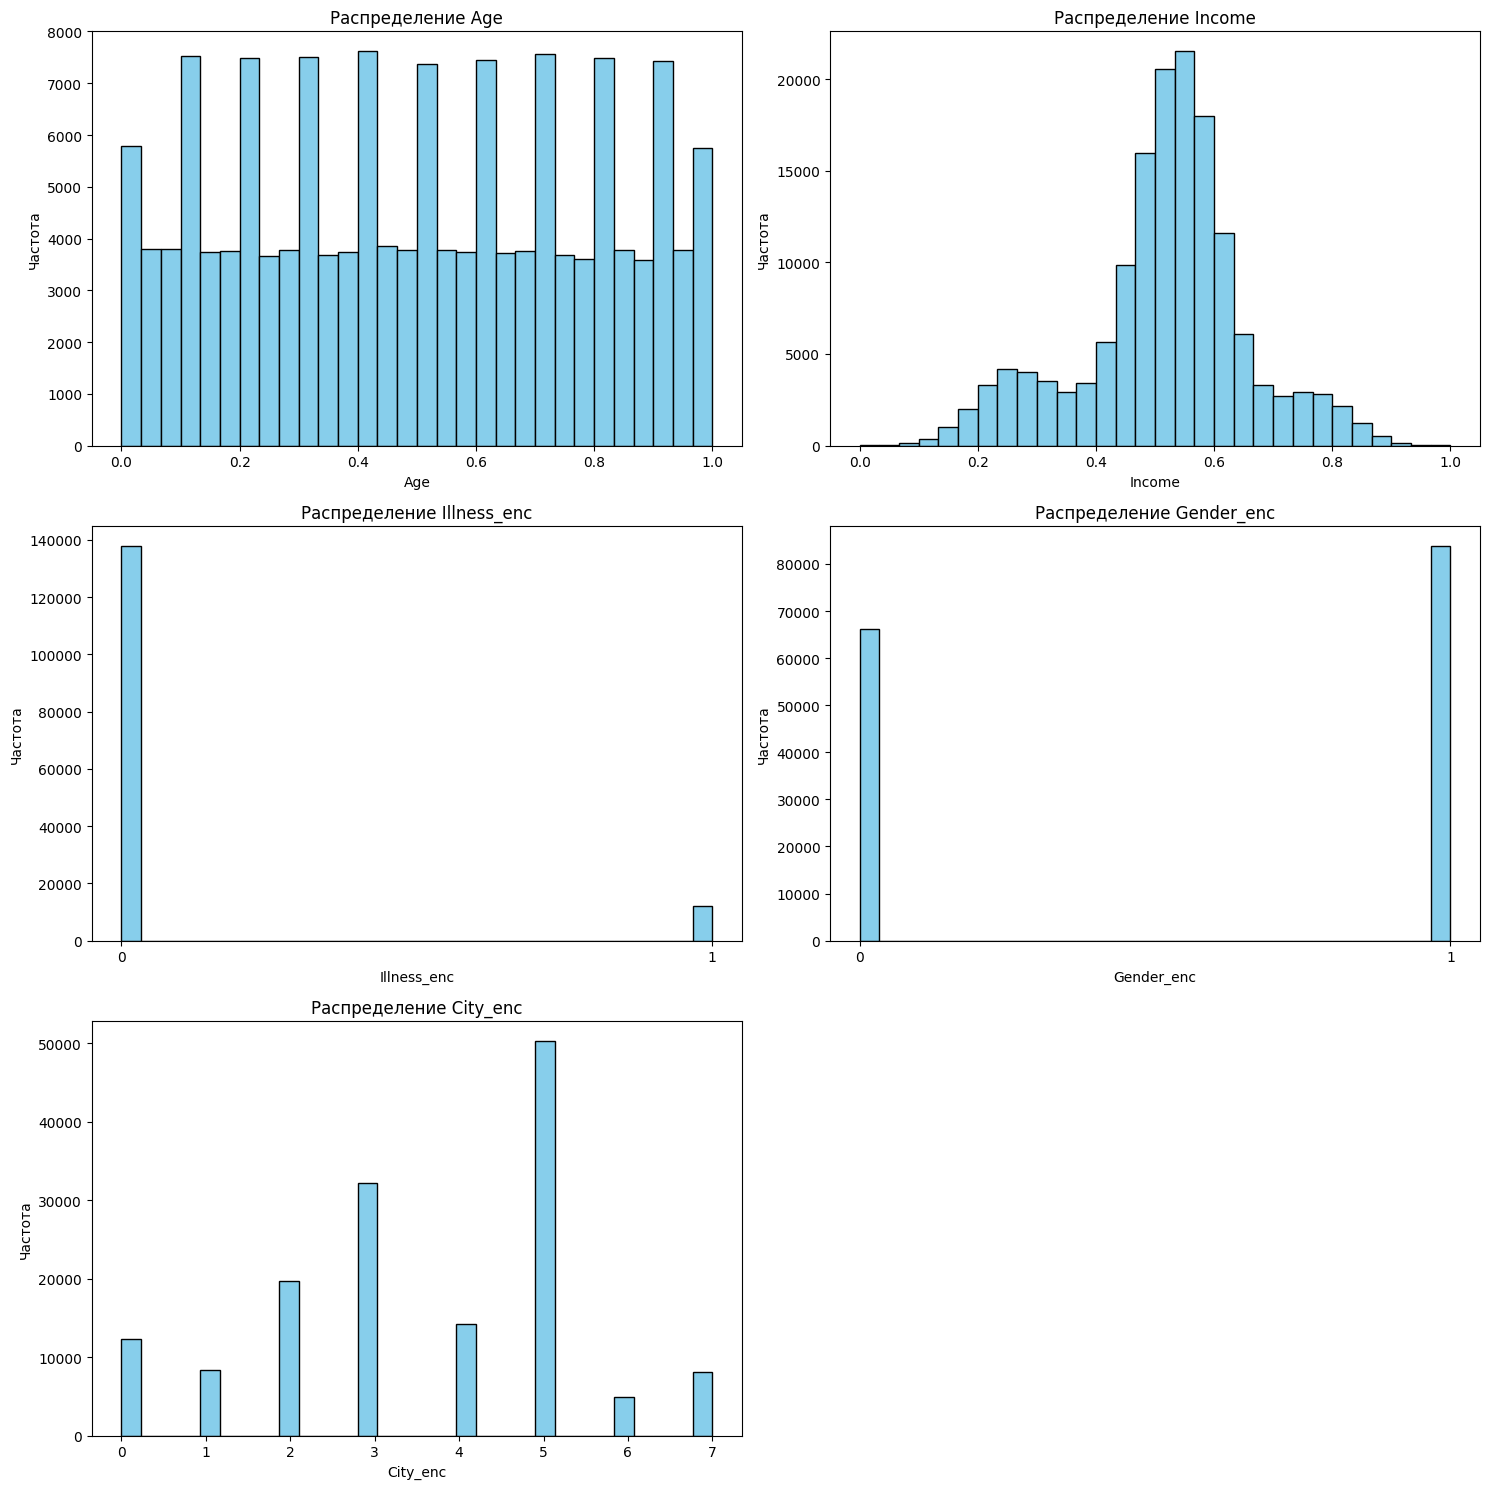

In [ ]:
n_cols = 2
n_rows = (len(all_num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(all_num_cols):
    axes[i].hist(df_num[col], bins=30, edgecolor='black', color='skyblue')
    axes[i].set_title(f'Распределение {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Частота', fontsize=10)
    if col in ['Gender_enc', 'Illness_enc']:
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['0', '1'])

for i in range(len(all_num_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Матрица корреляции

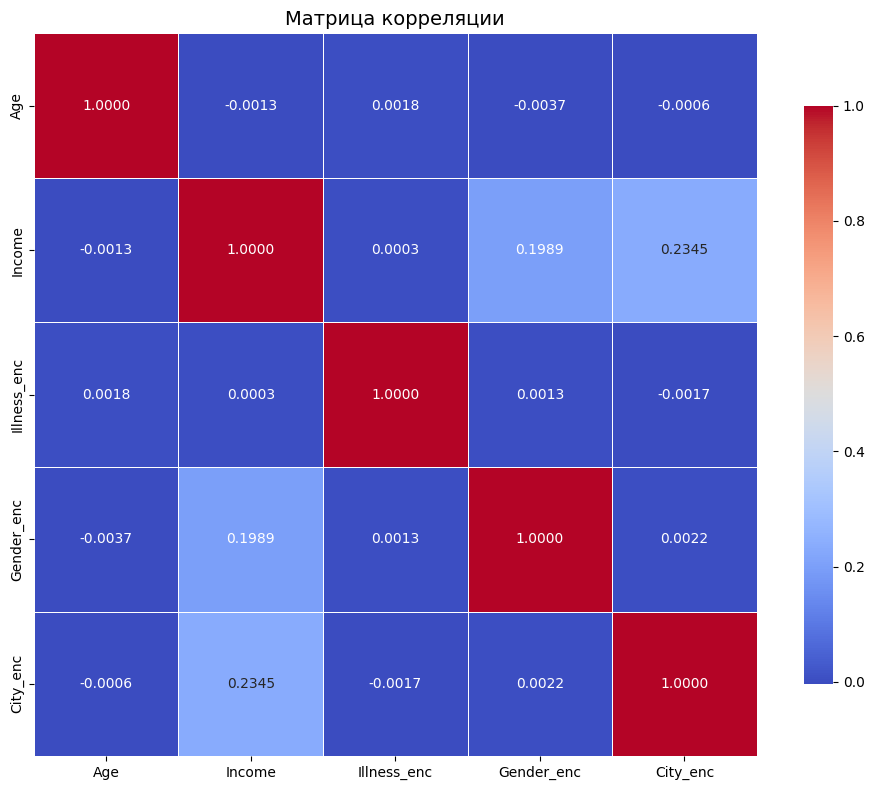

In [ ]:
full_corr_matrix = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляции', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод

Практически все столбцы показывают корреляцию стремящуюся к 0. Можно попробовать построить модель, предсказывающую значение income на основе столбцов Gender и City, так как они имееют слабую положительную связь (коэффициент корреляции около 0.2). Корреляция между City и Gender стремится к нулю, следовательно данные не дублируют друг друга и могут использоваться вместе.